In [1]:
%matplotlib inline
import mysql.connector          # MySQL se connect karne ke liye
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    conn = mysql.connector.connect(
        host='localhost',
        user='root',
        password='ROOT@#$%123456789',  # APNA PASSWORD DAALO
        database='sales_db'
    )
    print("MySQL connection successful!")
except mysql.connector.Error as err:
    print(f"Connection error: {err}")
    print("Check: MySQL chal raha hai? Password sahi hai?")
    raise

query = """
SELECT
    order_id,
    customer,
    product,
    category,
    city,
    quantity,
    unit_price,
    (quantity * unit_price) AS revenue,
    order_date
FROM orders
ORDER BY order_date
"""

df = pd.read_sql(query, conn)
conn.close()
print(f"\nLoaded {len(df)} rows from MySQL")
print(df.head())

MySQL connection successful!

Loaded 45 rows from MySQL
   order_id      customer     product     category       city  quantity  \
0         1  Rahul Sharma      Laptop  Electronics     Mumbai         1   
1         2   Priya Singh  Smartphone  Electronics      Delhi         2   
2         3    Amit Kumar  Headphones  Electronics  Bangalore         3   
3         4    Neha Gupta  Desk Chair    Furniture    Chennai         1   
4         5   Rohit Verma      Laptop  Electronics     Mumbai         1   

   unit_price  revenue  order_date  
0     55000.0  55000.0  2024-01-05  
1     18000.0  36000.0  2024-01-08  
2      2500.0   7500.0  2024-01-12  
3      8500.0   8500.0  2024-01-15  
4     72000.0  72000.0  2024-01-20  


C:\Users\Dell\AppData\Local\Temp\ipykernel_16476\1686282292.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [3]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month']      = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')

revenue_arr = df['revenue'].values.astype(float)  # NumPy array

total_rev  = np.sum(revenue_arr)
avg_rev    = np.mean(revenue_arr)
max_rev    = np.max(revenue_arr)
min_rev    = np.min(revenue_arr)
std_rev    = np.std(revenue_arr)
max_idx    = np.argmax(revenue_arr) 
print("="*50)
print("  SALES REVENUE ANALYSIS (NumPy)")
print("="*50)
print(f"Total Revenue     : Rs. {total_rev:,.0f}")
print(f"Average Order     : Rs. {avg_rev:,.0f}")
print(f"Highest Order     : Rs. {max_rev:,.0f} ({df.iloc[max_idx]['customer']})")
print(f"Lowest Order      : Rs. {min_rev:,.0f}")
print(f"Std Deviation     : Rs. {std_rev:,.0f}")

  SALES REVENUE ANALYSIS (NumPy)
Total Revenue     : Rs. 1,026,600
Average Order     : Rs. 22,813
Highest Order     : Rs. 75,000 (Sanjay Mehta)
Lowest Order      : Rs. 1,800
Std Deviation     : Rs. 20,981


In [4]:
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
print("\nCategory-wise Revenue:")
print(cat_rev.to_string())


Category-wise Revenue:
category
Electronics    888600.0
Furniture      138000.0



Chart saved: mysql_revenue_chart.png


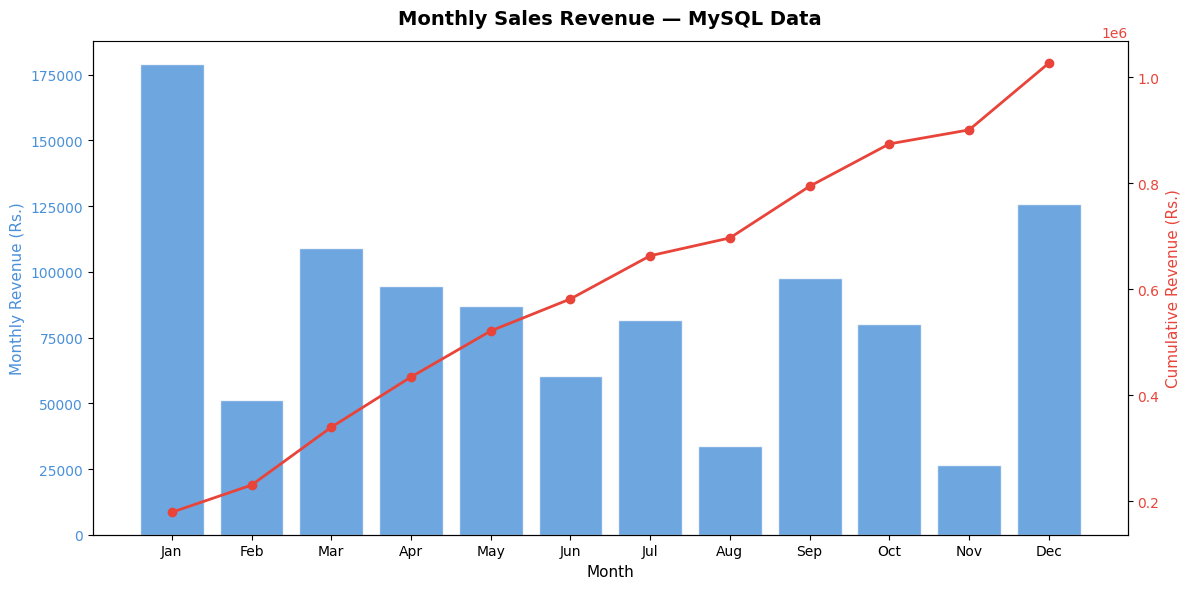

[Program 3 Complete]


In [5]:
monthly = df.groupby(['month','month_name'])['revenue'].sum().reset_index()
monthly = monthly.sort_values('month')

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart — monthly revenue
bars = ax1.bar(monthly['month_name'], monthly['revenue'],
               color='#4A90D9', alpha=0.8, edgecolor='white')
ax1.set_ylabel('Monthly Revenue (Rs.)', color='#4A90D9', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#4A90D9')

# Cumulative revenue line — second y axis
ax2 = ax1.twinx()   # Same x-axis, naya y-axis dayi taraf
cumrev = monthly['revenue'].cumsum()   # Cumulative sum
ax2.plot(monthly['month_name'], cumrev,
         color='#E8443A', marker='o', linewidth=2, label='Cumulative')
ax2.set_ylabel('Cumulative Revenue (Rs.)', color='#E8443A', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#E8443A')

ax1.set_title('Monthly Sales Revenue — MySQL Data', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Month', fontsize=11)
ax1.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('mysql_revenue_chart.png', dpi=150, bbox_inches='tight')
print("\nChart saved: mysql_revenue_chart.png")
plt.show()
print("[Program 3 Complete]")